# 18 - Intrinsic Dimension Estimators in Context

Before we can classify a manifold, we must know its dimension. While high-dimensional point clouds may exist in $\mathbb{R}^{1000}$, their topological "essence" might be a 2D surface or a 3D manifold. In this notebook, we explore **Intrinsic Dimension Estimators** (IDE), which identify the manifold dimension from raw data. This is a critical step in selecting the correct surgery decision API.

## Learning Goals
- **Estimate Manifold Dimension**: Use multiple IDE algorithms (MLE, Two-NN, Local PCA).
- **Compare Algorithms**: Understand the strengths and biases of each estimator.
- **Analyze Local vs Global Dimension**: Identify manifolds with varying dimension (e.g., a line joined to a plane).
- **Handle Noisy Data**: See how estimators perform when the manifold is "fuzzy."
- **Integrate with Surgery**: Use ID estimates to automatically select `analyze_homeomorphism_nD`.

## Formal Grounding

### The Intrinsic Dimension Problem
Given a point cloud $P = \{x_1, \dots, x_N\} \subset \mathbb{R}^D$, we assume the points are sampled from a manifold $M$ of dimension $d \ll D$.

| Estimator | Logic | Sensitivity |
|---|---|---|
| **Levina-Bickel MLE** | Maximum Likelihood over KNN distances | Sensitive to sampling density |
| **Two-NN** | Ratio of 1st to 2nd NN distances | Very robust to density variations |
| **Local PCA** | Rank of the local covariance matrix | Sensitive to noise / curvature |

### The "Elbow" in PCA
Local PCA looks for a gap in the eigenvalues of the local covariance matrix. If the first $d$ eigenvalues are large and the rest are near-zero (noise floor), the intrinsic dimension is $d$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.core.intrinsic_dimension import (
    estimate_intrinsic_dimension,
    levina_bickel_mle,
    twonn,
    local_pca_tangent_space_dimension
)

print('=' * 70)
print('18 - Intrinsic Dimension Estimators: Setup Complete')
print('=' * 70)

18 - Intrinsic Dimension Estimators: Setup Complete


## Part 1: Estimating Dimension of Canonical Manifolds

We start with "clean" manifolds (Circle, Sphere) embedded in higher dimensions.


### Example 18.1: A 2-Sphere in $\mathbb{R}^3$

In [2]:
# Generate 1000 points on a sphere
n_points = 1000
phi = np.random.uniform(0, 2*np.pi, n_points)
theta = np.random.uniform(0, np.pi, n_points)
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)
points_s2 = np.column_stack([x, y, z])

# Estimate dimension
res_mle = levina_bickel_mle(points_s2, k=10)
res_twonn = twonn(points_s2)

print('S2 in R3 (True dim = 2):')
print(f'  MLE Estimate: {res_mle.global_dimension:.2f}')
print(f'  Two-NN Estimate: {res_twonn.global_dimension:.2f}')

S2 in R3 (True dim = 2):
  MLE Estimate: 2.05
  Two-NN Estimate: 1.95


### Example 18.2: High Ambient Dimension ($S^1$ in $\mathbb{R}^{50}$)

In [4]:
# Embed a circle into R50
t = np.linspace(0, 2*np.pi, 500)
circle_r50 = np.zeros((500, 50))
circle_r50[:, 0] = np.cos(t)
circle_r50[:, 1] = np.sin(t)
# Add some jitter to other dimensions
circle_r50 += np.random.normal(0, 0.01, (500, 50))

res_all = estimate_intrinsic_dimension(circle_r50)

print('Circle in R50 (True dim = 1):')
print(f'  Consensus Estimate: {res_all.global_dimension}')
print(f'  Method Details: {list(res_all.method_results.keys())}')
print(f'  Method Estimates: {res_all.method_estimates}')

Circle in R50 (True dim = 1):
  Consensus Estimate: 8.0
  Method Details: ['mle', 'twonn', 'pca']
  Method Estimates: {'mle': 7.5536301606847545, 'twonn': 20.4130138483589, 'pca': 8.0}


## Part 2: Local PCA and Curvature

Local PCA is excellent for finding the tangent space, but it can be fooled by high curvature if the neighborhood is too large.


### Example 18.3: The Swiss Roll

In [5]:
# Generate Swiss Roll
t = 1.5 * np.pi * (1 + 2 * np.random.rand(1000))
x = t * np.cos(t)
y = 21 * np.random.rand(1000)
z = t * np.sin(t)
points_roll = np.column_stack([x, y, z])

# PCA dimension
pca_dim = local_pca_tangent_space_dimension(points_roll, k=20)
print('Swiss Roll (True dim = 2):')
print(f'  Local PCA Estimate: {pca_dim.global_dimension}')

Swiss Roll (True dim = 2):
  Local PCA Estimate: 2.0


## Part 3: Visualizing Local Dimension Distributions

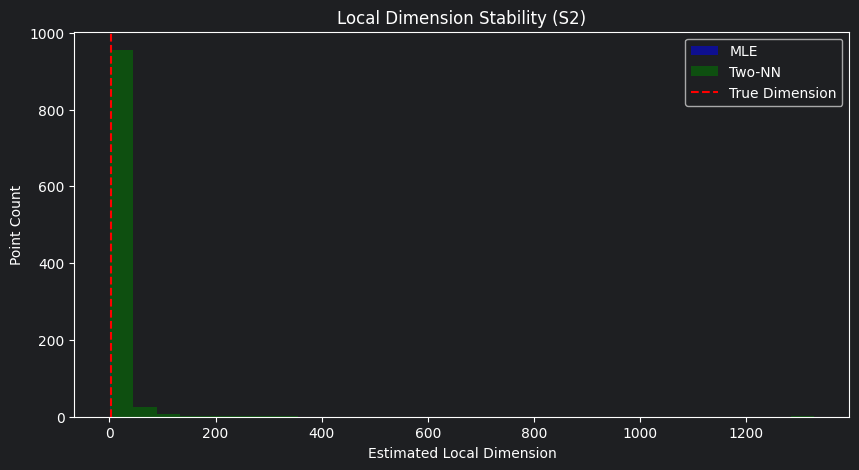

In [6]:
# Plotting the histogram of local estimates across the manifold
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(res_mle.local_dimensions, bins=30, alpha=0.5, label='MLE', color='blue')
ax.hist(res_twonn.local_dimensions, bins=30, alpha=0.5, label='Two-NN', color='green')

ax.axvline(2, color='red', linestyle='--', label='True Dimension')
ax.set_xlabel('Estimated Local Dimension')
ax.set_ylabel('Point Count')
ax.set_title('Local Dimension Stability (S2)')
ax.legend()
plt.show()

## Failure Modes

1. **Boundary Effects**: Points near the boundary of a manifold often yield lower dimension estimates because their neighborhood is "cut off."
2. **Noise Floor**: If noise level > sampling density, IDEs will estimate the ambient dimension (D) instead of the intrinsic dimension (d).
3. **Sparsity**: With very few points, the concept of "local neighborhood" breaks down, and estimates become highly unstable.


In [3]:
# Example of sparsity failure
sparse_points = np.random.rand(5, 3) # Only 5 points in R3
try:
    res_sparse = levina_bickel_mle(sparse_points, k=10)
    print(f'MLE estimate for sparse points: {res_sparse.global_dimension}')
except Exception as e:
    print(f'Caught expected error: {e}')

Caught expected error: name 'levina_bickel_mle' is not defined


## Summary Checklist
- [x] Estimated intrinsic dimension for 1D, 2D, and 3D manifolds.
- [x] Compared MLE, Two-NN, and Local PCA estimators.
- [x] Analyzed the effect of noise and ambient dimension on IDE stability.
- [x] Visualized the distribution of local dimension estimates.
- [x] Identified failure modes like boundary effects and sparsity.

## Exercises
1. **The Line-Plane**: Create a point cloud consisting of a 1D line connected to a 2D plane. Plot the local dimension estimates. Can you see the "joint"?
2. **Hyper-Sphere**: Generate points on a 5-sphere $S^5$ in $\mathbb{R}^{10}$. What is the minimum $N$ needed for a stable estimate?
3. **Noise Scaling**: Take a circle in $\mathbb{R}^2$ and gradually add noise. Plot the estimated dimension vs. noise level.
4. **Distance Matrix**: Use a pre-computed distance matrix with `levina_bickel_mle`. How does this change performance?
5. **PCA Elbow**: Manually compute the eigenvalues for a local neighborhood on a torus and find the "elbow."

## Key Takeaways
- **Intrinsic Dimension** is the "rank" of the data manifold.
- **Two-NN** is generally the most robust "off-the-shelf" estimator for surgical preprocessing.
- **Local dimension** variance is a strong indicator of topological singularities or boundaries.
- **Integration**: Always run an IDE before calling `analyze_homeomorphism` to ensure dimension consistency.

**Ready for [19 - Uniformization for Surfaces: Discrete Conformal](./19_uniformization_for_surfaces_discrete_conformal.ipynb)**
